# Rapid Risk Audit - Monte Carlo Analysis

We start by importing NumPy to perform numerical and statistical operations.
We then import Matplotlib to visualise the simulation results graphically.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

We then define the results from five hypothetical experts, each providing calibrated interval estimates for likelihood and financial impact of an AI incident.

In [ ]:
# Expert intervals (likelihood as decimals, impact in dollars)
experts = [
    {'name': 'Alex',    'likelihood': (0.10, 0.30), 'impact': (100000, 400000)},
    {'name': 'Bianca',  'likelihood': (0.15, 0.35), 'impact': (150000, 450000)},
    {'name': 'Charlie', 'likelihood': (0.20, 0.40), 'impact': (200000, 500000)},
    {'name': 'Dalia',   'likelihood': (0.12, 0.32), 'impact': (120000, 420000)},
    {'name': 'Emily',   'likelihood': (0.18, 0.38), 'impact': (180000, 480000)},
]

We then run num_simulations (10,000) Monte Carlo simulations. In each simulation, we randomly select an expert using np.random.choice(experts) and sample a likelihood and impact from their intervals using np.random.uniform(*expert['likelihood']) and np.random.uniform(*expert['impact']). We multiply these values to get an expected_loss and append this result to the results list. Finally, we calculate summary statistics: the mean loss (average_loss), as well as the 5th and 95th percentile losses (loss_5th, loss_95th), using NumPy’s mean and percentile functions.

In [ ]:
num_simulations = 10000
results = []
selected_experts = []

# Run simulations
for _ in range(num_simulations):
    # Randomly select one expert per simulation
    expert = np.random.choice(experts)

    # Randomly sample likelihood and impact from selected expert's intervals
    likelihood = np.random.uniform(*expert['likelihood'])
    impact = np.random.uniform(*expert['impact'])

    # Calculate expected loss
    expected_loss = likelihood * impact
    results.append(expected_loss)
    selected_experts.append(expert['name'])

# Summary statistics
average_loss = np.mean(results)
loss_5th = np.percentile(results, 5)
loss_95th = np.percentile(results, 95)

# Print results
print(f"Average Expected Loss: ${average_loss:,.2f}")
print(f"90% of expected losses range between: ${loss_5th:,.2f} and ${loss_95th:,.2f}")

Optionally, we calculate how often each expert was selected during the simulations by counting occurrences of their names in the selected_experts list. We store these counts in the expert_counts dictionary and print the selection frequency as both raw counts and percentages of total simulations (num_simulations). We do this to check whether each expert's input is proportionally represented in our simulation, ensuring no single expert disproportionately influences the results. By examining the selection frequency, we gain insight into how evenly distributed expert judgments were, helping validate the robustness and fairness of our risk estimates.

In [ ]:
# Optional: count expert selections
expert_counts = {expert['name']: selected_experts.count(expert['name']) for expert in experts}
print("\nExpert selection frequency:")
for name, count in expert_counts.items():
    print(f"{name}: {count} times ({(count/num_simulations)*100:.1f}%)")

Now let's plot it

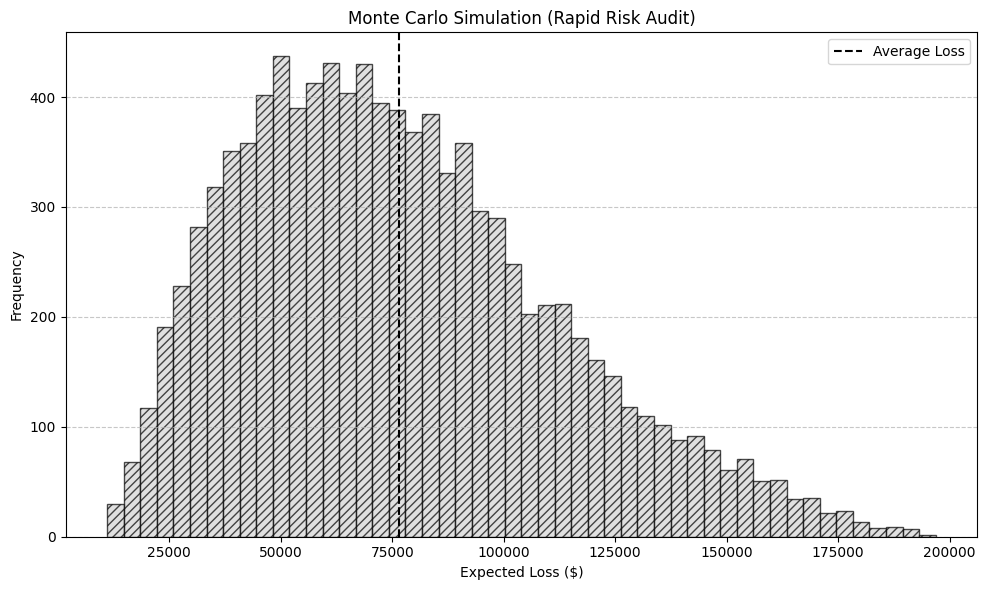

In [ ]:
# Plotting
plt.figure(figsize=(10, 6))
plt.hist(results, bins=50, color='lightgrey', edgecolor='black', hatch='////', alpha=0.7)
plt.axvline(average_loss, color='black', linestyle='--', linewidth=1.5, label='Average Loss')
plt.title("Monte Carlo Simulation (Rapid Risk Audit)")
plt.xlabel("Expected Loss ($)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
